# Imported Race-Session Database Surface EDA

This notebook audits the other imported race-session data surfaces in
Race Telemetry Workbench: session metadata, drivers, weather,
track/session status, race control, circuit markers, raw telemetry
coverage, raw position coverage, ingestion diagnostics, and aligned
10 Hz replay data.

It complements `2025_telemetry_bad_lap_eda.ipynb`, which focuses on
lap-level telemetry shape and bad-lap taxonomy.


## Scope

Race sessions are the default project scope. This notebook includes
all imported race sessions in the local database and clearly separates
complete-season 2025 coverage from partial 2024 and 2026 imports.


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from notebooks import database_surface_quality_support as eda
print(f"artifact dir: {eda.ARTIFACT_DIR}")


artifact dir: /Users/fabio/Workspace/race-telemetry-workbench/artifacts/race-database-surface-eda


## Installed Skrub API

The EDA uses `skrub.TableReport` for a compact dataframe profile.
`SKB_DATA_DIRECTORY` and the Matplotlib `Agg` backend are configured
by the support module before importing `skrub`.


In [2]:
import inspect
import skrub

print("skrub version:", skrub.__version__)
print("TableReport:", inspect.signature(skrub.TableReport))


skrub version: 0.9.0
TableReport: (dataframe, n_rows=10, order_by=None, title=None, column_filters=None, verbose=None, plot_distributions='auto', compute_associations='auto', open_tab='table', max_plot_columns=None, max_association_columns=None)


## Run The Surface Audit

The support module builds one row per imported race session and
supporting tables for ingestion diagnostics, aligned quality flags,
and race-control category mix.


In [3]:
result = eda.run_analysis(write_outputs=True)

classified = result["classified"]
flag_summary = result["flag_summary"]
year_summary = result["year_summary"]
diagnostics = result["diagnostics"]
aligned_flags = result["aligned_flags"]
race_control_categories = result["race_control_categories"]

print(f"race sessions inspected: {len(classified)}")
print(f"sessions with at least one surface issue: {classified['has_surface_issue'].sum()}")
print(f"summary: {result['summary_path']}")
print(f"skrub report: {result['report_path']}")


/Users/fabio/Workspace/race-telemetry-workbench/notebooks/database_surface_quality_support.py:490: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result["ingestion_diagnostic_warning"] = result["ingestion_diagnostic_warning"].fillna(False).astype(bool)


race sessions inspected: 32
sessions with at least one surface issue: 32
summary: /Users/fabio/Workspace/race-telemetry-workbench/docs/data-quality/race-database-surface-eda-summary.md
skrub report: /Users/fabio/Workspace/race-telemetry-workbench/artifacts/race-database-surface-eda/skrub_database_surface_report.html


## Year-Level Coverage

2025 is the complete-season slice. 2024 and 2026 are partial imports
and should not be interpreted as complete season coverage.


In [4]:
display(year_summary)
display(classified[['year','event_name','driver_count','lap_rows','telemetry_samples','position_samples','aligned_samples','weather_samples','race_control_messages','corner_markers','surface_issue_count']])


,year,sessions,sessions_with_issue,median_surface_issue_count,telemetry_samples,position_samples,aligned_samples,weather_samples,race_control_messages,issue_pct
0,2024,1,1,1.0,324545,333502,0,133,59,100.0
1,2025,24,24,2.0,9113457,9314091,24477559,3781,2178,100.0
2,2026,7,7,2.0,2826311,2330236,6706847,1142,1205,100.0


,year,event_name,driver_count,lap_rows,telemetry_samples,position_samples,aligned_samples,weather_samples,race_control_messages,corner_markers,surface_issue_count
0,2024,Italian Grand Prix,20,1008,324545,333502,0,133,59,11,1
1,2025,Australian Grand Prix,20,927,372477,380930,999583,178,113,14,3
2,2025,Chinese Grand Prix,20,1065,392448,398411,1049027,154,56,16,2
3,2025,Japanese Grand Prix,20,1059,371291,379525,994294,140,23,18,2
4,2025,Bahrain Grand Prix,20,1128,425177,436990,1144940,158,91,15,2
5,2025,Saudi Arabian Grand Prix,20,898,333314,336779,885764,142,65,27,2
6,2025,Miami Grand Prix,20,1005,356089,362855,955079,149,77,19,3
7,2025,Emilia Romagna Grand Prix,20,1207,393149,400409,1055536,150,44,19,2
8,2025,Monaco Grand Prix,20,1425,420152,429303,1131575,160,196,19,2
9,2025,Spanish Grand Prix,19,1203,378908,388975,1019335,155,100,14,2


## Surface Quality Flags

These are session-level flags, not per-lap flags. A session can be
useful for replay and still have a surface flag that deserves
documentation or follow-up.


In [5]:
display(flag_summary)


,surface_flag,sessions,pct_sessions
6,ingestion_diagnostic_warning,31,96.875
2,lap_metadata_incomplete,25,78.125
9,race_control_sparse_or_untimed,16,50.000
5,aligned_replay_quality_issue,2,6.250
10,circuit_annotation_issue,1,3.125
1,driver_metadata_sparse,0,0.000
4,raw_position_coverage_issue,0,0.000
3,raw_telemetry_coverage_issue,0,0.000
0,session_metadata_incomplete,0,0.000
8,status_timeline_sparse,0,0.000


## Ingestion Diagnostics And Aligned Replay Quality

Raw telemetry coverage and aligned replay quality are different
surfaces. The aligned table can carry quality flags even when raw
streams are present.


In [6]:
display(diagnostics.head(25))
display(aligned_flags.groupby('quality_flag', as_index=False)['rows'].sum().sort_values('rows', ascending=False))


,session_id,year,event_name,driver_code,driver_number,stream_name,sample_count,min_delta_ms,median_delta_ms,p90_delta_ms,p99_delta_ms,max_delta_ms,estimated_frequency_hz,duplicate_count,out_of_order_count,warning_flags
0,2025-australian-grand-prix-r,2025,Australian Grand Prix,ALB,23,raw_car_telemetry,22873,158.0,240.0,399.0,520.0,1359.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
1,2025-australian-grand-prix-r,2025,Australian Grand Prix,ALB,23,raw_location_telemetry,23398,20.0,240.0,380.0,520.0,1380.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
2,2025-australian-grand-prix-r,2025,Australian Grand Prix,ALO,14,raw_car_telemetry,13022,158.0,240.0,399.0,481.0,1359.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
3,2025-australian-grand-prix-r,2025,Australian Grand Prix,ALO,14,raw_location_telemetry,13336,20.0,240.0,380.0,500.0,1340.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
4,2025-australian-grand-prix-r,2025,Australian Grand Prix,ANT,12,raw_car_telemetry,22862,158.0,240.0,399.0,520.0,1359.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
5,2025-australian-grand-prix-r,2025,Australian Grand Prix,ANT,12,raw_location_telemetry,23388,20.0,240.0,380.0,520.0,1380.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
6,2025-australian-grand-prix-r,2025,Australian Grand Prix,BEA,87,raw_car_telemetry,22980,158.0,240.0,399.0,520.0,1359.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
7,2025-australian-grand-prix-r,2025,Australian Grand Prix,BEA,87,raw_location_telemetry,23505,20.0,240.0,380.0,520.0,1380.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
8,2025-australian-grand-prix-r,2025,Australian Grand Prix,BOR,5,raw_car_telemetry,18661,158.0,240.0,399.0,520.0,1359.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
9,2025-australian-grand-prix-r,2025,Australian Grand Prix,BOR,5,raw_location_telemetry,19083,20.0,240.0,380.0,520.0,1340.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE


,quality_flag,rows
4,OK,30017592
2,LOCATION_GAP_TOO_LARGE,862777
3,LOCATION_SAMPLE_TOO_OLD,732254
0,CAR_GAP_TOO_LARGE,343959
1,CAR_SAMPLE_TOO_OLD,183357


## Race-Control Message Mix

Race-control messages are a storytelling surface. This table checks
category/scope distribution and timing completeness before any
incident taxonomy work.


In [7]:
display(race_control_categories.head(50))


,session_id,year,event_name,category,flag,scope,messages,missing_session_time,lap_scoped,driver_scoped
0,2024-italian-grand-prix-r,2024,Italian Grand Prix,Other,missing,missing,28,3,28,0
1,2024-italian-grand-prix-r,2024,Italian Grand Prix,Flag,BLUE,Driver,26,0,26,26
2,2024-italian-grand-prix-r,2024,Italian Grand Prix,Flag,GREEN,Track,2,1,2,0
3,2024-italian-grand-prix-r,2024,Italian Grand Prix,Drs,missing,missing,2,1,2,0
4,2024-italian-grand-prix-r,2024,Italian Grand Prix,Flag,CHEQUERED,Track,1,0,1,0
5,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Other,missing,missing,84,4,84,0
6,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Flag,BLUE,Driver,9,0,9,9
7,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Flag,BLACK AND WHITE,Driver,7,0,7,7
8,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Drs,missing,missing,2,1,2,0
9,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Flag,GREEN,Track,2,1,2,0


## Visual Artifacts


artifacts/race-database-surface-eda/figures/surface_availability_heatmap.svg


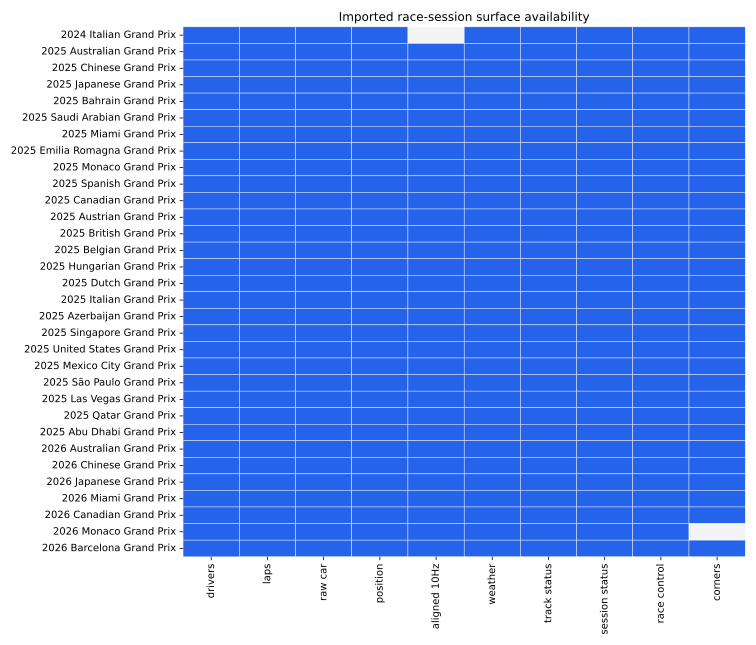

artifacts/race-database-surface-eda/figures/surface_issue_counts.svg


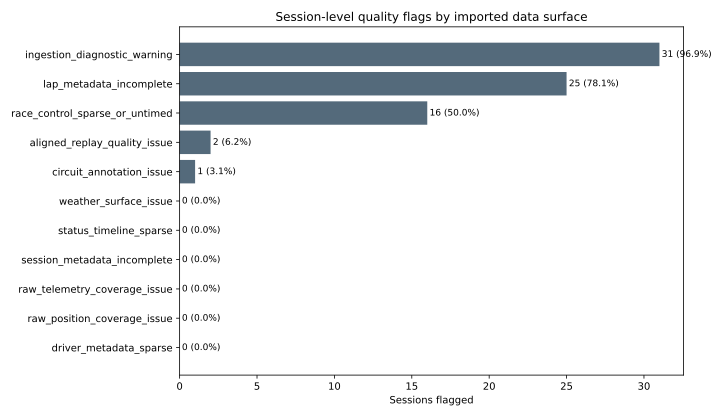

artifacts/race-database-surface-eda/figures/context_density_by_session.svg


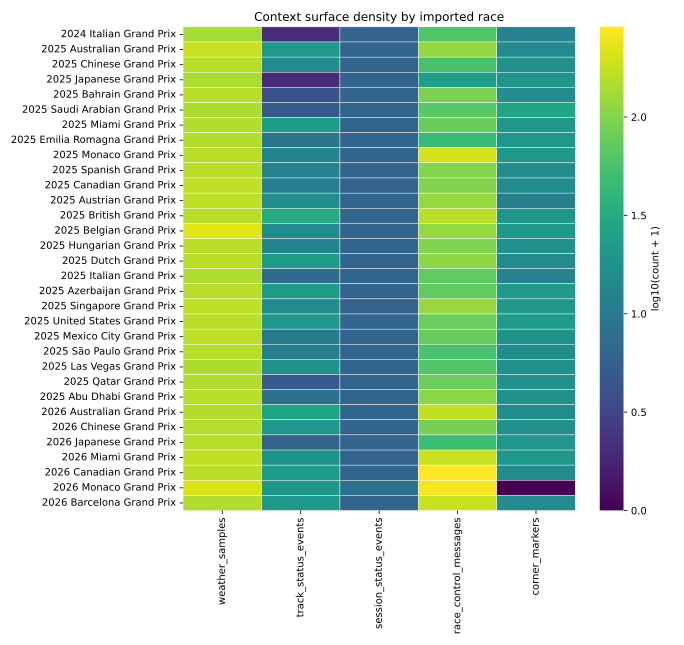

artifacts/race-database-surface-eda/figures/ingestion_frequency_by_stream.svg


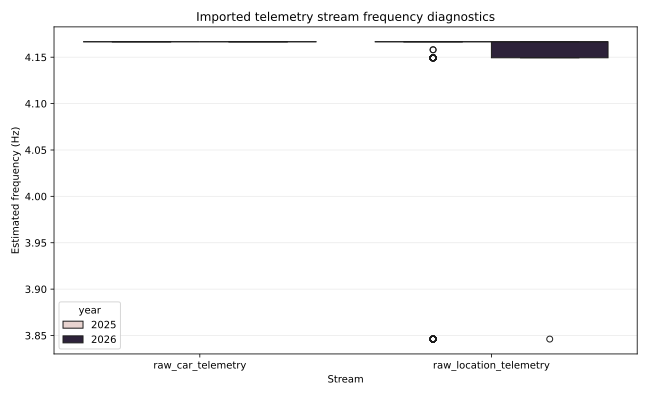

artifacts/race-database-surface-eda/figures/race_control_category_mix.svg


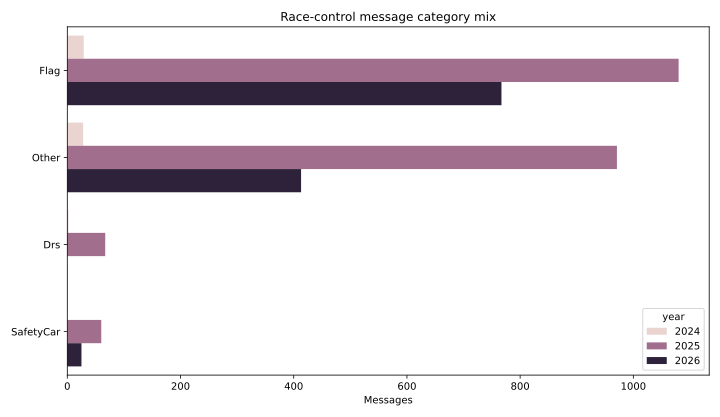

In [8]:
from IPython.display import SVG, display

for path in result["figure_paths"]:
    print(path.relative_to(REPO_ROOT))
    display(SVG(filename=str(path)))


## Outputs

Primary outputs:

- `docs/data-quality/race-database-surface-eda-summary.md`
- `artifacts/race-database-surface-eda/skrub_database_surface_report.html`
- `artifacts/race-database-surface-eda/tables/*.csv`
- `artifacts/race-database-surface-eda/tables/session_surface_quality.parquet`
- `artifacts/race-database-surface-eda/figures/*.svg`

The next useful iteration is to decode aligned `quality_flags` by
session, driver, lap, and time window, then connect those findings
back to replay behavior.
